# Lire le dataset issu de l'étape exploration

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
df = pd.read_csv("../data/processed/step1_exploration.csv")

print("Shape:", df.shape)
df.head()

Shape: (4372, 53)


,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,...,LoyaltyLevel,ChurnRiskCategory,WeekendPreference,BasketSizeCategory,ProductDiversity,Gender,AccountStatus,Country,Churn,MonetaryTotal_log
0,17850,302,35,5288.63,16.950737,13.603662,-30.60,107.25,1693,5.426282,...,Jeune,Critique,Inconnu,Moyen,Explorateur,Unknown,Active,United Kingdom,1,8.573504
1,13047,32,18,3079.10,15.709694,11.684769,-15.00,68.00,1355,6.913265,...,Établi,Moyen,Semaine,Moyen,Explorateur,M,Active,United Kingdom,0,8.032717
2,12583,3,18,7187.34,28.634821,23.150132,-60.84,132.80,5009,19.956175,...,Ancien,Faible,Semaine,Grand,Explorateur,Unknown,Active,France,0,8.880216
3,13748,96,5,948.25,33.866071,42.953119,9.36,204.00,439,15.678571,...,Établi,Critique,Inconnu,Grand,Explorateur,Unknown,Active,United Kingdom,1,6.855672
4,15100,330,6,635.10,105.850000,215.986263,-131.40,350.40,58,9.666667,...,Jeune,Critique,Inconnu,Moyen,Spécialisé,M,Active,United Kingdom,1,6.455356


 1. Diagnostic global

✔️ Types et valeurs manquantes

In [43]:
df.info()
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

print("Colonnes avec valeurs manquantes :")
print(missing)


<class 'pandas.DataFrame'>
RangeIndex: 4372 entries, 0 to 4371
Data columns (total 53 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 4372 non-null   int64  
 1   Recency                    4372 non-null   int64  
 2   Frequency                  4372 non-null   int64  
 3   MonetaryTotal              4372 non-null   float64
 4   MonetaryAvg                4372 non-null   float64
 5   MonetaryStd                4372 non-null   float64
 6   MonetaryMin                4372 non-null   float64
 7   MonetaryMax                4372 non-null   float64
 8   TotalQuantity              4372 non-null   int64  
 9   AvgQuantityPerTransaction  4372 non-null   float64
 10  MinQuantity                4372 non-null   int64  
 11  MaxQuantity                4372 non-null   int64  
 12  CustomerTenureDays         4372 non-null   int64  
 13  FirstPurchaseDaysAgo       4372 non-null   int64  
 14  Pre

✔️ Visualisation des NaN

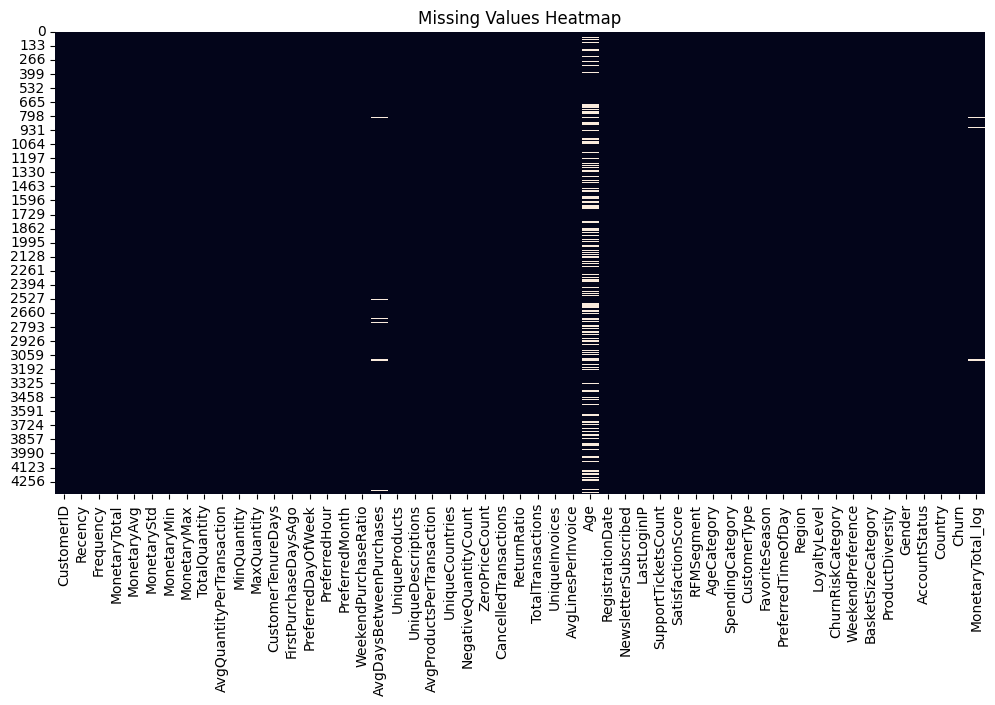

In [44]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

# Nettoyage des valeurs manquantes


1. Age (30% manquant)


In [45]:
median_age = df['Age'].median() #calcule la médiane des âges
df['Age'] = df['Age'].fillna(median_age) #remplace les valeurs manquantes par médiane

2. AvgDaysBetweenPurchases

In [46]:
df['AvgDaysBetweenPurchases'] = df['AvgDaysBetweenPurchases'].fillna(
    df['AvgDaysBetweenPurchases'].median()
)

3. MonetaryTotal_log

In [47]:
df['MonetaryTotal_log'] = np.log1p(df['MonetaryTotal'])
df = df.fillna(df.median(numeric_only=True))


c:\Users\chaie\OneDrive\Desktop\projetML\projetML\venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


4. SupportTickets

In [48]:
df['SupportTicketsCount'] = df['SupportTicketsCount'].replace([-1, 999], np.nan) #remplace les valeurs aberrantes par NaN
df['SupportTicketsCount'] = df['SupportTicketsCount'].fillna(df['SupportTicketsCount'].median()) #remplace les valeurs manquantes par la médiane

5. Satisfaction

In [49]:
df["SatisfactionScore"] = df["SatisfactionScore"].replace([-1, 99], np.nan) #où tu vois -1 ou 99, efface-les et mets 'vide' (NaN)
df["SatisfactionScore"] = df["SatisfactionScore"].fillna(df["SatisfactionScore"].median()) #remplir les vides". On utilise la médiane

# Vérification intermédiaire

In [50]:
df.isnull().sum().sort_values(ascending=False) 
#Vérifie combien de NaN restent par colonne après le traitement.
#sort_values(ascending=False) affiche d’abord les colonnes avec le plus de valeurs manquantes

CustomerID                   0
Recency                      0
Frequency                    0
MonetaryTotal                0
MonetaryAvg                  0
MonetaryStd                  0
MonetaryMin                  0
MonetaryMax                  0
TotalQuantity                0
AvgQuantityPerTransaction    0
MinQuantity                  0
MaxQuantity                  0
CustomerTenureDays           0
FirstPurchaseDaysAgo         0
PreferredDayOfWeek           0
PreferredHour                0
PreferredMonth               0
WeekendPurchaseRatio         0
AvgDaysBetweenPurchases      0
UniqueProducts               0
UniqueDescriptions           0
AvgProductsPerTransaction    0
UniqueCountries              0
NegativeQuantityCount        0
ZeroPriceCount               0
CancelledTransactions        0
ReturnRatio                  0
TotalTransactions            0
UniqueInvoices               0
AvgLinesPerInvoice           0
Age                          0
RegistrationDate             0
Newslett

# Traitement des valeurs aberrantes

✔️ Visualisation

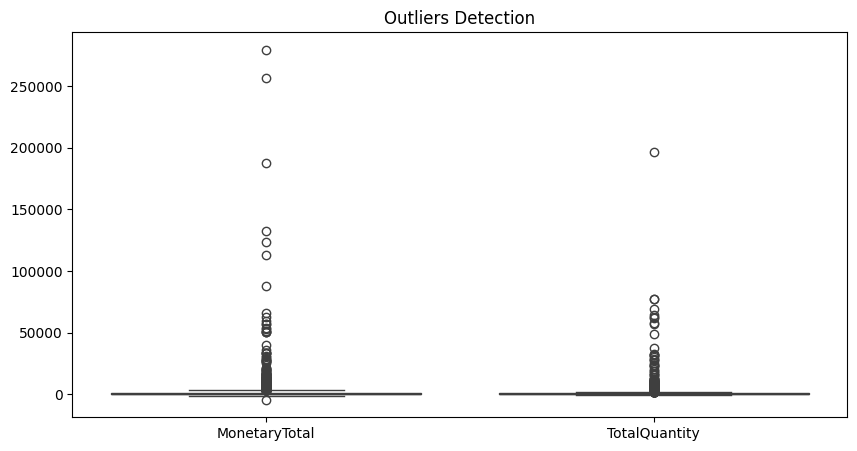

In [51]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df[['MonetaryTotal', 'TotalQuantity']])
plt.title("Outliers Detection")
plt.show()

✔️ Correction

In [52]:
df['TotalQuantity'] = df['TotalQuantity'].clip(lower=0)
df['MinQuantity'] = df['MinQuantity'].clip(lower=0)


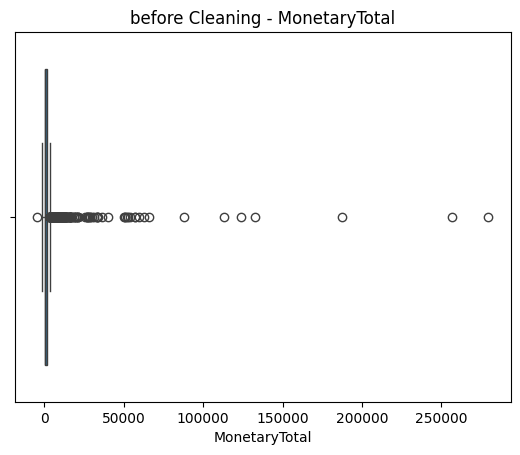

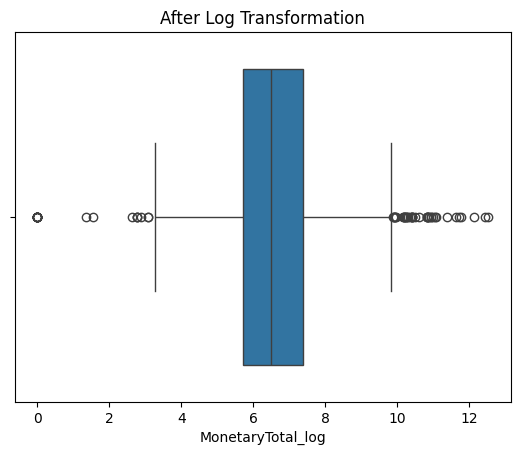

In [53]:
sns.boxplot(x=df['MonetaryTotal'])
plt.title("before Cleaning - MonetaryTotal")
plt.show()
sns.boxplot(x=df['MonetaryTotal_log'])
plt.title("After Log Transformation")
plt.show()


# Suppression des features inutiles
1. NewsletterSubscribed (valeur constante)

In [54]:
df.drop("NewsletterSubscribed", axis=1, inplace=True)

print("Newsletter" in df.columns) 


False


2. LastLoginIP

In [55]:
df.drop("LastLoginIP", axis=1, inplace=True)

print("LastLoginIP" in df.columns)

False


# Parsing de RegistrationDate
1. Convertir en format date

In [56]:
df["RegistrationDate"] = pd.to_datetime(
    df["RegistrationDate"],#cible
    dayfirst=True,#tu forces Python à comprendre que le premier chiffre est le Jou
    errors="coerce"
)

# Vérifier le type de la colonne
print(f"Nouveau type de la colonne : {df['RegistrationDate'].dtype}")

# Vérifier s'il y a eu des erreurs de conversion (NaT)
print(f"Nombre d'erreurs de date : {df['RegistrationDate'].isnull().sum()}")

Nouveau type de la colonne : datetime64[us]
Nombre d'erreurs de date : 0


C:\Users\chaie\AppData\Local\Temp\ipykernel_15280\1167783641.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["RegistrationDate"] = pd.to_datetime(


2. Extraction

In [57]:
df['RegYear'] = df['RegistrationDate'].dt.year
df['RegMonth'] = df['RegistrationDate'].dt.month
df['RegDay'] = df['RegistrationDate'].dt.day
df['RegWeekday'] = df['RegistrationDate'].dt.weekday


3. Suppression

In [58]:
df.drop(columns=['RegistrationDate'], inplace=True)

# Visualisation pour valider le nettoyage

In [59]:
print("NaN restants :", df.isnull().sum().sum())
df.isnull().sum()
print("Shape final :", df.shape)
df.describe()
df[df.isnull().any(axis=1)]


NaN restants : 0
Shape final : (4372, 54)


,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,...,ProductDiversity,Gender,AccountStatus,Country,Churn,MonetaryTotal_log,RegYear,RegMonth,RegDay,RegWeekday


# Sauvegarde

In [60]:
df.to_csv("../data/processed/step2_cleaning.csv", index=False)
print(f"Données sauvegardées ")

Données sauvegardées 
